In [1]:
import numpy as np

At a lunar magnetic anomaly, electrons and magnetised and ions are not. To prove this, we need to compare some characteristic lengths to show that the anomaly is large compared to electron and scales and small compared to ion scales. 

We proceed as follows:

In [2]:
# --- Physical constants (SI) --------------------------------------------
e     = 1.602176634e-19   # C
m_p   = 1.67262192e-27    # kg
m_e   = 9.1093837e-31     # kg
mu_0  = 1.25663706e-6     # H/m
eps_0 = 8.8541878e-12     # F/m
c     = 2.99792458e8      # m/s

# --- Inputs (all SI) -----------------------------------------------------
n_sw   = 5.0e6      # m^-3   (= 5 cm^-3, nominal 1 AU)
v_sw   = 400e3      # m/s    bulk speed
B_imf  = 5e-9       # T
kT_p   = 10.0 * e   # J      (10 eV)  -- includes k_B
kT_e   = 12.0 * e   # J      (12 eV)
gamma  = 5/3        # conventional; not rigorous in a collisionless plasma
kappa  = 0.88       # momentum-transfer efficiency (gas-dynamic convention)

B_surf = 300e-9     # T      strong anomaly, order of magnitude
d_src  = 30e3       # m      source depth  -- TODO: dominant uncertainty
L_anom = 50e3       # m      horizontal anomaly scale -- TODO: from Mitchell 2008

rho = n_sw * m_p    # kg/m^3

# --- Scale functions -----------------------------------------------------
def r_gyro(m, v, B):        return m * v / (e * B)
def d_inertial(m, n):       return np.sqrt(m / (mu_0 * n * e**2))
def debye(kT, n):           return np.sqrt(eps_0 * kT / (n * e**2))
def v_thermal(kT, m):       return np.sqrt(2 * kT / m)

# --- Ambient solar wind --------------------------------------------------
v_th_e = v_thermal(kT_e, m_e)

r_p   = r_gyro(m_p, v_sw,   B_imf)   # proton gyroradius. CONVECTIVE - bulk speed, see note
r_e   = r_gyro(m_e, v_th_e, B_imf)   # electron gyroradius. thermal - electrons are ~isotropic
d_i   = d_inertial(m_p, n_sw)        # ion (proton) inertial length
d_e   = d_inertial(m_e, n_sw)        # electron inertial length
lam_D = debye(kT_e, n_sw)            # Debye length

In the IMF regime, far from Moon:

In [10]:
print("ion inertial length: ", d_i, "m")

ion inertial length:  101835.3509288139 m


Calculate standoff altitude and field strength at anomaly boundary, assuming:
1. Normal incidence at sub-solar nose
2. Stagnation (no mass flow across boundary), no normal field across boundary, i.e. tangential discontinuity at boundary
3. No plasma source at lunar surface, lunar surface absorbs incident plasma
4. Cold & hypersonic solar wind

(For full derivation, see OneNote > Derivations > Standoff Altitude)

In [8]:
P_dyn = kappa * rho * v_sw**2          # solar wind pressure
B_so  = np.sqrt(2 * mu_0 * P_dyn)      # magnetic pressure
z_so  = d_src * ((B_surf / B_so)**(1/3) - 1)   # standoff height where pressure equilibrates
print(f"Standoff B: {B_so*1e9:.1f} nT,  Standoff height: {z_so/1e3:.1f} km")

Standoff B: 54.4 nT,  Standoff height: 23.0 km


From standoff altitude and field strength, calculate proton and electron gyroradii at anomaly boundary:

In [13]:
r_p_anom = r_gyro(m_p, v_sw,   B_so)
r_e_anom = r_gyro(m_e, v_th_e, B_so)

print("Proton gyroradius at anomaly boundary:", r_p_anom)
print("Electron gyroradius at anomaly boundary:", r_e_anom)

print("Compared to horizontal anomaly size:")
for name, scale in [("r_p", r_p_anom), ("d_i", d_i), ("d_e", d_e)]:
    print(f"L / {name} = {L_anom/scale:.1f}")

Proton gyroradius at anomaly boundary: 76761.28396023772
Electron gyroradius at anomaly boundary: 214.72853969435485
Compared to horizontal anomaly size:
L / r_p = 0.7
L / d_i = 0.5
L / d_e = 21.0


Conclusion: the inequality d_e ≪ L ≲ d_i, r_p holds, i.e. the anomaly scale is much larger than electron scales, and smaller than ion scales.

Now for some visualisation:

Fig. 1: Scale hierarchy

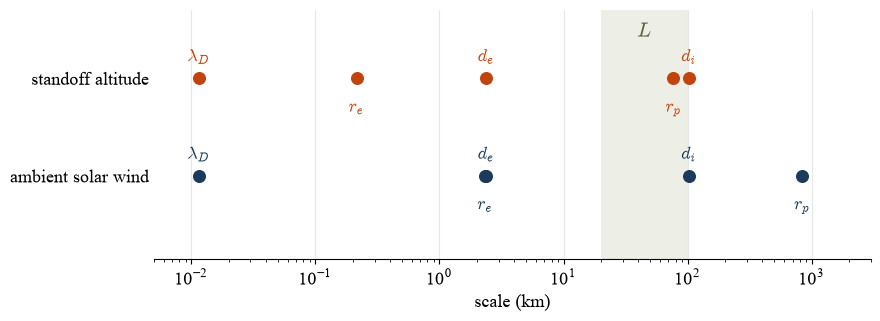

In [28]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'font.size': 13,
})

# --- data ----------------------------------------------------------------
# z_so row is the argument so it goes on top
scales = {  # km
    'standoff altitude': {r'$\lambda_D$': 0.0115, r'$r_e$': 0.215, r'$d_e$': 2.38,
                     r'$r_p$': 76.8, r'$d_i$': 101.8},
    'ambient solar wind':      {r'$\lambda_D$': 0.0115, r'$r_e$': 2.34,  r'$d_e$': 2.38,
                     r'$d_i$': 101.8, r'$r_p$': 835},
}

palette = ['#c1440e', '#1b3a5c']          # rust (z_so), deep blue (ambient)

# Gyroradii below the row, inertial/Debye lengths above.
offsets = {r'$\lambda_D$': 12, r'$d_e$': 12, r'$d_i$': 12,
           r'$r_e$': -24, r'$r_p$': -24}

# --- plot ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 3.4))

ax.axvspan(20, 100, alpha=0.15, color='#8a8f5c', zorder=0, lw=0)
ax.text(45, 1.42, r'$L$', ha='center', color='#5c6136', fontsize=15)

for i, (env, d) in enumerate(scales.items()):
    y = 1 - i
    ax.scatter(list(d.values()), [y] * len(d),
               s=70, color=palette[i], zorder=3)
    for name, val in d.items():
        ax.annotate(name, (val, y), textcoords='offset points',
                    xytext=(0, offsets[name]), ha='center',
                    color=palette[i], fontsize=13)

ax.set_xscale('log')
ax.set_xlim(5e-3, 3e3)
ax.set_ylim(-0.85, 1.7)
ax.set_yticks([1, 0])
ax.set_yticklabels(scales.keys())
ax.set_xlabel('scale (km)')
ax.grid(axis='x', alpha=0.3)
ax.tick_params(axis='y', length=0)
for side in ('top', 'right', 'left'):
    ax.spines[side].set_visible(False)

fig.tight_layout()
fig.savefig('../figures/scale_hierarchy.pdf')
plt.show()